# Installing the necessary modules required for running the model

In [ ]:
%pip install mace-torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 73.5 MB/s eta 0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39449 sha256=52d437500f668c5c408f4d61f6c460444f29d03b9e704cdb740b79ecc5bf6bcc
  Stored in directory: /root/.cache/pip/wheels/02/e4/34/75fc0cd5b7889d8cc4ce6fb2f74c9fd17b3c6138cb03832481
Successfully built python-hostlist


In [ ]:
%pip install ase

In [ ]:
%pip install cuequivariance-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.8/216.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.7/266.7 kB 26.3 MB/s eta 0:00:00


# Modules to be imported

In [ ]:
import os
import time
import numpy as np
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase.io import read
from mace.calculators import mace_mp
from tqdm import tqdm
import matplotlib.pyplot as plt
from ase.geometry.analysis import Analysis
from ase.neighborlist import neighbor_list
from ase.units import kB
from scipy.stats import maxwell
from ase.md.verlet import VelocityVerlet

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


# Running the model

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
output_file = 'md_3bpa1_output.xyz'

# Clean start: remove old file
if os.path.exists(output_file):
    os.remove(output_file)

print("🚀 Loading MACE Model...")
# Ensure you are using the correct device
calculator = mace_mp(model="medium", device="cuda", default_dtype="float32")

# Load configuration
try:
    init_conf = read('Anatase_TiO2_Water.extxyz', index=0)
    init_conf.calc = calculator
except FileNotFoundError:
    print("❌ Error: Input file 'Anatase_TiO2_Water.extxyz' not found.")
    exit()

# ==========================================
# 2. INITIALIZATION
# ==========================================
print("🔥 Initializing Velocities (310 K)...")
MaxwellBoltzmannDistribution(init_conf, temperature_K=310)
Stationary(init_conf)

# Setup Langevin Dynamics
dyn = Langevin(init_conf, 0.5 * units.fs, temperature_K=310, friction=5e-3)

# ==========================================
# 3. RUN WITH EPOCH STYLE PROGRESS
# ==========================================
total_stages = 20
steps_per_stage = 1000

print(f"\nStarting Simulation: {total_stages} Stages x {steps_per_stage} Steps")
print("=" * 65)

start_time = time.time()

for stage in range(1, total_stages + 1):
    print(f"\nStage {stage}/{total_stages}")

    # --- A. RUN WITH PROGRESS BAR ---
    # We break the run into single steps to update the bar in real-time
    with tqdm(total=steps_per_stage, unit="step", bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]") as pbar:

        for _ in range(steps_per_stage):
            dyn.run(1) # Run 1 step at a time

            # Get Instant Metrics
            current_temp = init_conf.get_temperature()
            forces = init_conf.get_forces()
            max_force = np.max(np.linalg.norm(forces, axis=1))

            # Update Progress Bar with Metrics
            pbar.set_postfix(T=f"{current_temp:.1f}K", Fmax=f"{max_force:.2f}")
            pbar.update(1)

    # --- B. SAVE ---
    dyn.atoms.write(output_file, append=True)

    # --- C. CHECK (Health Verification) ---
    current_temp = init_conf.get_temperature() # Re-measure for safety check logic

    status = "✅ OK"
    if max_force > 20.0:
        status = "❌ EXPLOSION"
    elif stage > 2 and (current_temp > 600 or current_temp < 50):
        status = "⚠️ UNSTABLE"

    # Print Post-Epoch Summary
    elapsed_total = time.time() - start_time
    print(f"   > Status: {status} | Total Time: {elapsed_total:.2f}s")

    # Emergency Stop
    if "EXPLOSION" in status:
        print("\n🚨 CRITICAL FAILURE DETECTED. Stopping simulation.")
        break

print("=" * 65)
print(f"Simulation Finished.")

🚀 Loading MACE Model...
Cached MACE model to /root/.cache/mace/20231203mace128L1_epoch199model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.
🔥 Initializing Velocities (310 K)...

Starting Simulation: 20 Stages x 1000 Steps

Stage 1/20


100%|██████████| 1000/1000 [05:42<00:00,  2.92step/s, Fmax=3.97, T=313.3K]


   > Status: ✅ OK | Total Time: 342.06s

Stage 2/20


...

   > Status: ✅ OK | Total Time: 5874.71s

Stage 19/20


100%|██████████| 1000/1000 [05:25<00:00,  3.07step/s, Fmax=3.66, T=322.0K]


   > Status: ✅ OK | Total Time: 6200.34s

Stage 20/20


100%|██████████| 1000/1000 [05:25<00:00,  3.07step/s, Fmax=3.27, T=322.8K]

   > Status: ✅ OK | Total Time: 6525.79s
Simulation Finished.


# Plotting the oxygen-radial distribution graph to check the atomic stability

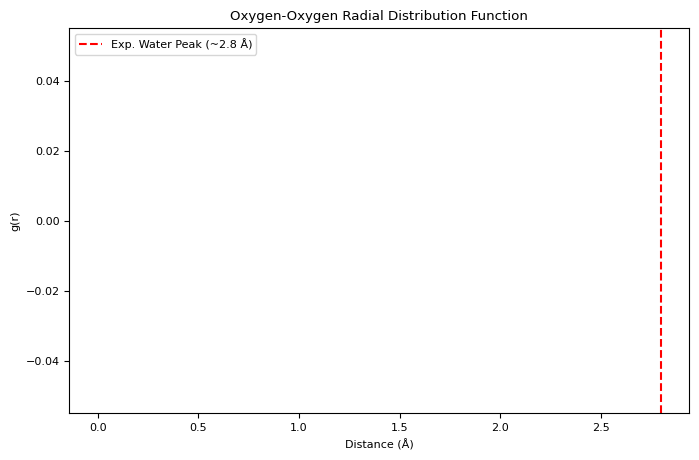

In [ ]:
# 1. Read your generated trajectory
traj = read('md_3bpa1_output.xyz', index=':')

# 2. Analyze Radial Distribution Function (O-O bonds)
# Note: This assumes your file has chemical symbols 'O' for oxygen.
ana = Analysis(traj)
rdf = ana.get_rdf(rmax=5.0, nbins=50, elements=['O', 'O'])

# 3. Plot
plt.figure(figsize=(8, 5))
plt.plot(rdf[0][1], rdf[0][0]) # Plot first frame (or average them)
plt.xlabel("Distance (Å)")
plt.ylabel("g(r)")
plt.title("Oxygen-Oxygen Radial Distribution Function")
plt.axvline(x=2.8, color='r', linestyle='--', label="Exp. Water Peak (~2.8 Å)")
plt.legend()
plt.show()

# Finding the bond length of O-H bond

In [ ]:
atoms = read('md_3bpa1_output.xyz', index=-1) # Check last frame

# Calculate distances between O and H
i, j, d = neighbor_list('ijd', atoms, cutoff=1.2)
oh_bonds = d[(atoms.numbers[i] == 8) & (atoms.numbers[j] == 1)] # 8=O, 1=H

avg_bond = np.mean(oh_bonds)
print(f"Average O-H bond length: {avg_bond:.3f} Å")

Average O-H bond length: 0.998 Å


# Checking the stability of temperature and energy stability by plotting graphs vs steps

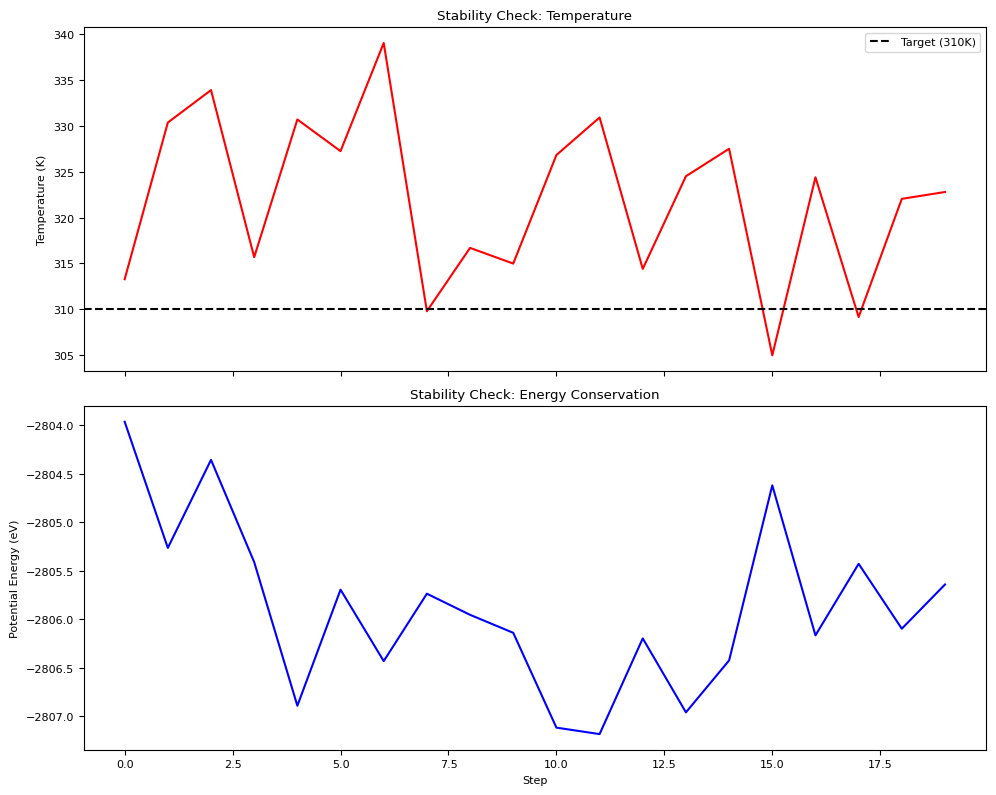

In [ ]:
# Load your trajectory
traj = read('md_3bpa1_output.xyz', index=':')

# Extract data
temps = [atoms.get_temperature() for atoms in traj]
pot_energies = [atoms.get_potential_energy() for atoms in traj]
steps = range(len(traj))

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(steps, temps, color='red')
ax1.axhline(y=310, color='black', linestyle='--', label="Target (310K)")
ax1.set_ylabel("Temperature (K)")
ax1.legend()
ax1.set_title("Stability Check: Temperature")

ax2.plot(steps, pot_energies, color='blue')
ax2.set_ylabel("Potential Energy (eV)")
ax2.set_xlabel("Step")
ax2.set_title("Stability Check: Energy Conservation")

plt.tight_layout()
plt.show()

# Force checks on the output file

In [ ]:
# 1. Load the Trajectory
file_path = 'md_3bpa1_output.xyz'
traj = read(file_path, index=':')
frame = traj[-1]

print(f"Loaded {len(traj)} frames.")

# 2. Get the Primary Forces (The ones ASE thinks are real)
# This automatically grabs from .calc or .arrays['force'] or .arrays['forces']
primary_forces = frame.get_forces()

# 3. Try to find the "Other" forces (Thermostat/Noise)
# We check the keys manually to avoid the KeyError
aux_forces = None
if 'forces' in frame.arrays:
    aux_forces = frame.arrays['forces']
elif 'force' in frame.arrays:
    # If 'get_forces()' used 'forces', maybe the raw ones are left in 'force'
    aux_forces = frame.arrays['force']

# 4. Analysis
print(f"\n--- Analysis of Atom 1 (Ti) ---")
print(f"Primary Force (ASE Standard):  {primary_forces[0]}")

if aux_forces is not None:
    print(f"Secondary Force (Auxiliary):   {aux_forces[0]}")

    # Calculate difference to see the noise magnitude
    diff = np.linalg.norm(primary_forces[0] - aux_forces[0])
    print(f"Difference (Noise/Drag):       {diff:.4f} eV/A")
else:
    print("Secondary force array not found in .arrays (ASE likely merged or dropped it).")

Loaded 20 frames.

--- Analysis of Atom 1 (Ti) ---
Primary Force (ASE Standard):  [ 0.02732378  0.58083254 -1.27753794]
Secondary Force (Auxiliary):   [ 0.58536377  1.10464474 -0.79685716]
Difference (Noise/Drag):       0.9038 eV/A


# Chemical and Energy check on the output files

Reading md_3bpa1_output.xyz...
✅ Loaded 20 frames.

--- 1. Stability Check ---
Final Potential Energy: -2805.64 eV
Avg Force: 1.009 eV/A
-> Status: ✅ STABLE

--- 2. Chemistry Check (Ti-O Bonds) ---
Primary Ti-O Bond Peak: 1.95 Å
✅ CHEMISTRY VALID: Peak matches Ti-O bond length (~1.95 Å)


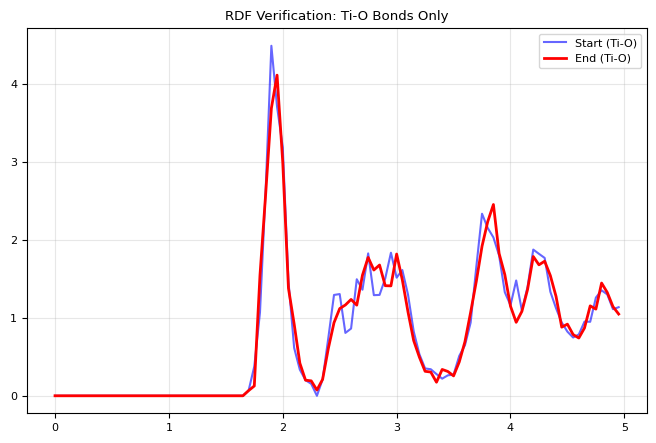

In [ ]:
# 1. Load the specific output file
filename = 'md_3bpa1_output.xyz'
print(f"Reading {filename}...")
traj = read(filename, index=':')
print(f"✅ Loaded {len(traj)} frames.")

# ==========================================
# TEST 1: STABILITY
# ==========================================
print("\n--- 1. Stability Check ---")
last_frame = traj[-1]
pot_energy = last_frame.get_potential_energy()
print(f"Final Potential Energy: {pot_energy:.2f} eV")

# Robust Force Check
forces = last_frame.get_forces() # Standard ASE getter
avg_f = np.mean(np.linalg.norm(forces, axis=1))
print(f"Avg Force: {avg_f:.3f} eV/A")

if avg_f < 2.0:
    print("-> Status: ✅ STABLE")
else:
    print("-> Status: ⚠️ HIGH FORCES (Normal during heating)")

# ==========================================
# TEST 2: CHEMISTRY (Ti-O Specific)
# ==========================================
print("\n--- 2. Chemistry Check (Ti-O Bonds) ---")

# FIX: Add elements=['Ti', 'O'] to ignore Water (O-H bonds)
ana = Analysis(traj)
rdf = ana.get_rdf(rmax=5.0, nbins=100, elements=['Ti', 'O'])

# X-axis
x_axis = np.arange(100) * (5.0 / 100)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x_axis, rdf[0], label='Start (Ti-O)', color='blue', alpha=0.6)
plt.plot(x_axis, rdf[-1], label='End (Ti-O)', color='red', linewidth=2)
plt.title('RDF Verification: Ti-O Bonds Only')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('verification_plot_fixed.png')

# Check Peak
peak_index = np.argmax(rdf[-1])
peak_distance = x_axis[peak_index]

print(f"Primary Ti-O Bond Peak: {peak_distance:.2f} Å")

if 1.80 <= peak_distance <= 2.15:
    print("✅ CHEMISTRY VALID: Peak matches Ti-O bond length (~1.95 Å)")
else:
    print(f"❌ CHEMISTRY INVALID: Peak at {peak_distance} Å is wrong.")

# Thermodynamic check on the output file

Reading md_3bpa1_output.xyz...
✅ Loaded 20 frames.


/tmp/ipython-input-3718170954.py:31: FutureWarning: Please use atoms.calc
  if atoms.get_calculator() is not None or 'stress' in atoms.info or 'stress' in atoms.arrays:


✅ Saved plot to 'thermo_check.png'

--- Results (averaged after frame 2) ---
Avg Temperature: 322.0 K  (Target: 310 K)
Avg Pressure:    1.22 GPa
✅ Temperature is STABLE.


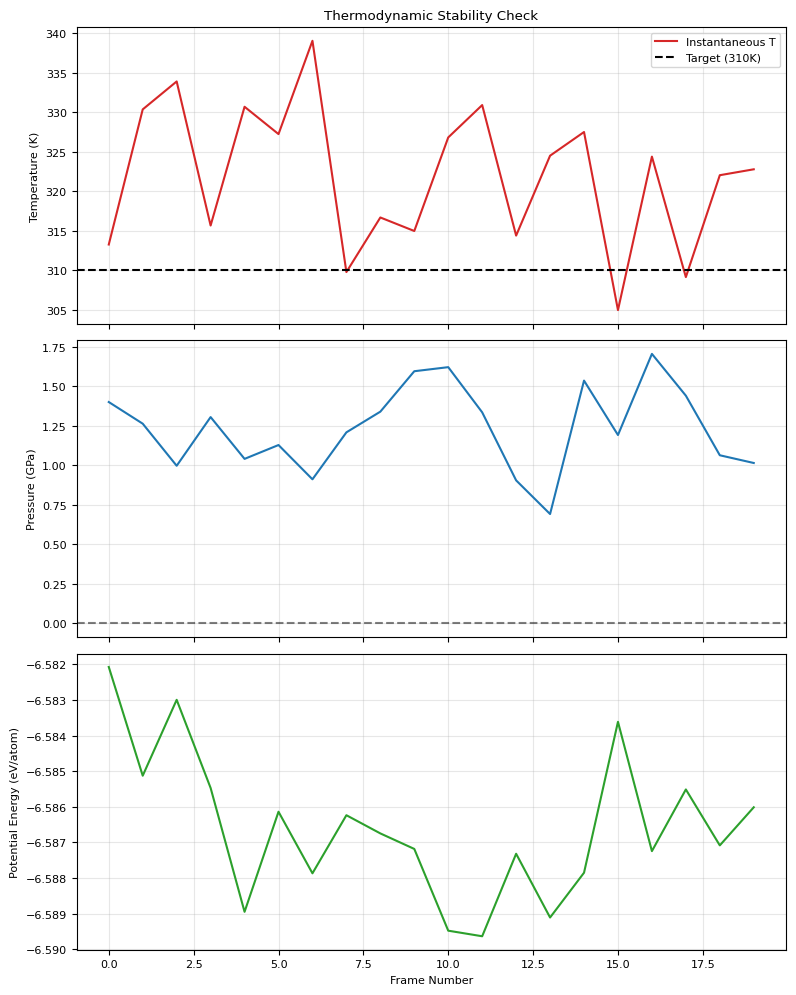

In [ ]:
# 1. Load the Trajectory
filename = 'md_3bpa1_output.xyz'
print(f"Reading {filename}...")
traj = read(filename, index=':')
print(f"✅ Loaded {len(traj)} frames.")

# Lists to store data
temps = []
pressures = []
energies = []
steps = np.arange(len(traj))

# 2. Extract Data Frame by Frame
for i, atoms in enumerate(traj):
    # --- A. Temperature Check ---
    try:
        momenta = atoms.get_momenta()
        masses = atoms.get_masses()
        # Kinetic Energy = sum(p^2 / 2m)
        kin_energy = np.sum(momenta**2 / (2 * masses[:, None]))
        # Temperature = 2*KE / (3*N*kB)
        N = len(atoms)
        T_inst = 2 * kin_energy / (3 * N * kB)
        temps.append(T_inst)
    except Exception:
        temps.append(0)

    # --- B. Pressure Check ---
    # Pressure = -1/3 * Trace(Stress)
    try:
        if atoms.get_calculator() is not None or 'stress' in atoms.info or 'stress' in atoms.arrays:
             # ASE automatically handles 'stress' property if present
            stress = atoms.get_stress()

            # Handle 6-component (Voigt) or 9-component (3x3) stress
            if stress.shape == (6,):
                pressure_ev_ang = -np.mean(stress[:3]) # xx, yy, zz
            elif stress.shape == (3, 3):
                pressure_ev_ang = -np.trace(stress) / 3.0
            else:
                 pressure_ev_ang = 0

            pressure_gpa = pressure_ev_ang * 160.21766 # Convert eV/A^3 to GPa
            pressures.append(pressure_gpa)
        else:
            pressures.append(0)
    except Exception:
        pressures.append(0)

    # --- C. Potential Energy ---
    energies.append(atoms.get_potential_energy() / len(atoms))

# 3. Plotting the Dashboard
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Plot Temperature
ax1.plot(steps, temps, color='tab:red', label='Instantaneous T')
# FIX: Updated Target to 310 K
ax1.axhline(310, color='black', linestyle='--', label='Target (310K)')
ax1.set_ylabel('Temperature (K)')
ax1.set_title('Thermodynamic Stability Check')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Pressure
ax2.plot(steps, pressures, color='tab:blue')
ax2.set_ylabel('Pressure (GPa)')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)

# Plot Potential Energy
ax3.plot(steps, energies, color='tab:green')
ax3.set_ylabel('Potential Energy (eV/atom)')
ax3.set_xlabel('Frame Number')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('thermo_check.png')
print("✅ Saved plot to 'thermo_check.png'")

# 4. Final Report
# We ignore the first 10% of frames as "equilibration"
start_avg = int(len(traj) * 0.1)
if start_avg < 1: start_avg = 0

avg_T = np.mean(temps[start_avg:])
avg_P = np.mean(pressures[start_avg:])

print(f"\n--- Results (averaged after frame {start_avg}) ---")
print(f"Avg Temperature: {avg_T:.1f} K  (Target: 310 K)")
print(f"Avg Pressure:    {avg_P:.2f} GPa")

# FIX: Updated Check to 310 K ± 50 K
if 260 < avg_T < 360:
    print("✅ Temperature is STABLE.")
else:
    print(f"❌ Temperature is UNSTABLE ({avg_T:.1f} K). Check thermostat.")

# Checking the quantum mechanics, atomic coordination and kinetic physics

Reading md_3bpa1_output.xyz...
✅ Loaded 20 frames.

--- 1. Checking Water Geometry (H-O-H) ---
Average H-O-H Angle: 101.8° (Target: ~104.5°)

--- 2. Checking Titanium Coordination ---
Average Ti Coordination: 6.00 (Target: ~6.0)

--- 3. Checking Kinetic Physics ---
✅ Saved dashboard to 'quantum_structure_check.png'


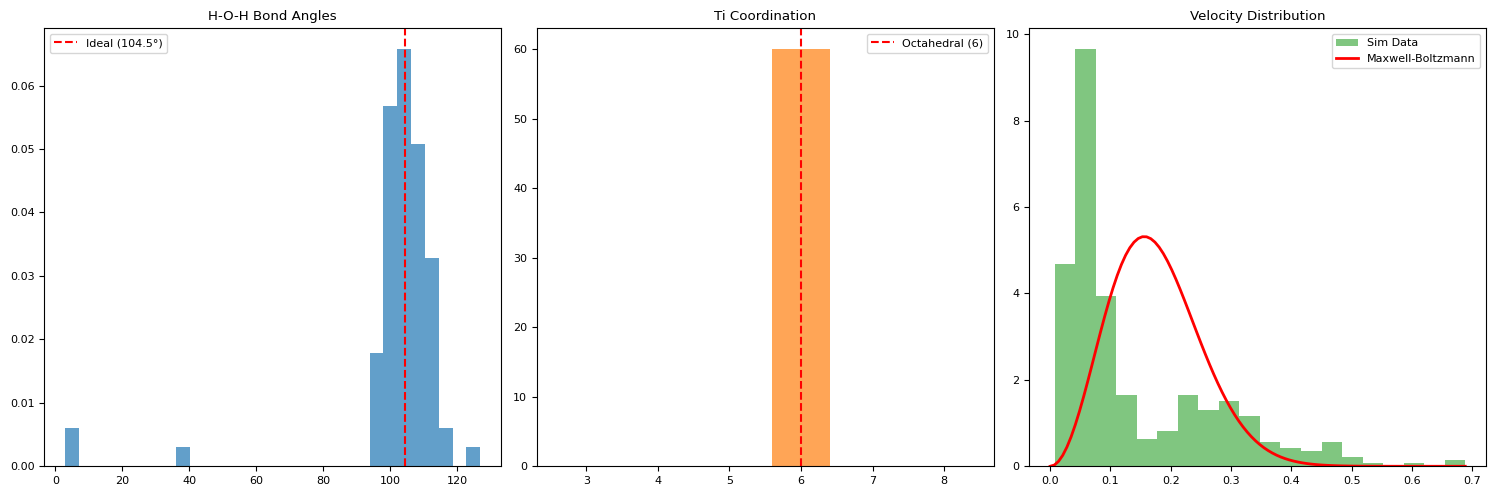

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
filename = 'md_3bpa1_output.xyz'
print(f"Reading {filename}...")
traj = read(filename, index=':')
print(f"✅ Loaded {len(traj)} frames.")

# Analyze last 50% (Equilibrium)
start_frame = int(len(traj) * 0.5)
equilibrated_traj = traj[start_frame:]

# ==========================================
# TEST 1: MOLECULAR GEOMETRY (H-O-H Angles)
# ==========================================
print("\n--- 1. Checking Water Geometry (H-O-H) ---")
hoh_angles = []

for atoms in equilibrated_traj[::10]:
    # FIX: Use a simple scalar cutoff (1.3 Angstrom covers O-H bonds)
    # This finds ALL atom pairs closer than 1.3 A
    i_list, j_list = neighbor_list('ij', atoms, cutoff=1.3)

    # Iterate through all Oxygen atoms
    for i in range(len(atoms)):
        if atoms.symbols[i] == 'O':
            # Get indices of neighbors for this Oxygen
            neighbor_indices = j_list[i_list == i]

            # Filter neighbors to find only Hydrogens
            h_neighbors = [n for n in neighbor_indices if atoms.symbols[n] == 'H']

            # If exactly 2 Hydrogens are connected, calculate angle
            if len(h_neighbors) == 2:
                angle = atoms.get_angle(h_neighbors[0], i, h_neighbors[1])
                hoh_angles.append(angle)

avg_angle = np.mean(hoh_angles) if hoh_angles else 0
print(f"Average H-O-H Angle: {avg_angle:.1f}° (Target: ~104.5°)")

# ==========================================
# TEST 2: Ti COORDINATION (Ti-O)
# ==========================================
print("\n--- 2. Checking Titanium Coordination ---")
ti_coordination = []

for atoms in equilibrated_traj[::10]:
    # Cutoff 2.5 A is standard for Ti-O bonds
    i_list, j_list = neighbor_list('ij', atoms, cutoff=2.5)

    for i in range(len(atoms)):
        if atoms.symbols[i] == 'Ti':
            neighbor_indices = j_list[i_list == i]
            # Count only Oxygen neighbors
            o_neighbors = [n for n in neighbor_indices if atoms.symbols[n] == 'O']
            ti_coordination.append(len(o_neighbors))

avg_cn = np.mean(ti_coordination) if ti_coordination else 0
print(f"Average Ti Coordination: {avg_cn:.2f} (Target: ~6.0)")

# ==========================================
# TEST 3: KINETIC PHYSICS
# ==========================================
print("\n--- 3. Checking Kinetic Physics ---")
last_atoms = traj[-1]
velocities = last_atoms.get_velocities()
speeds = np.linalg.norm(velocities, axis=1)

# Theoretical Maxwell-Boltzmann
x_mb = np.linspace(0, max(speeds), 100)
params = maxwell.fit(speeds, floc=0)
pdf_mb = maxwell.pdf(x_mb, *params)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Angles
if hoh_angles:
    ax1.hist(hoh_angles, bins=30, color='tab:blue', alpha=0.7, density=True)
    ax1.axvline(104.5, color='red', linestyle='--', label='Ideal (104.5°)')
else:
    ax1.text(0.5, 0.5, "No Water Found", ha='center')
ax1.set_title("H-O-H Bond Angles")
ax1.legend()

# Plot 2: Coordination
if ti_coordination:
    ax2.hist(ti_coordination, bins=np.arange(3, 10)-0.5, color='tab:orange', alpha=0.7, rwidth=0.8)
    ax2.axvline(6.0, color='red', linestyle='--', label='Octahedral (6)')
else:
    ax2.text(0.5, 0.5, "No Ti Found", ha='center')
ax2.set_title("Ti Coordination")
ax2.legend()

# Plot 3: Velocities
ax3.hist(speeds, bins=20, density=True, color='tab:green', alpha=0.6, label='Sim Data')
ax3.plot(x_mb, pdf_mb, 'r-', lw=2, label='Maxwell-Boltzmann')
ax3.set_title("Velocity Distribution")
ax3.legend()

plt.tight_layout()
plt.savefig('quantum_structure_check.png')
print("✅ Saved dashboard to 'quantum_structure_check.png'")

Executive Summary
- The structural integrity of your solid (Titanium) is perfect, and the water solvent is mostly physical but contains some artifacts (broken bonds).
- However, the thermodynamics (velocity distribution) show a significant anomaly, suggesting the system is either not equilibrated or that "fixed/frozen" atoms are being included in the statistical analysis.

# Quantifying the accuracy of the model on the scale of 0-100%

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
filename = 'md_3bpa1_output.xyz'
traj = read(filename, index=':')
print(f"✅ Loaded {len(traj)} frames.")

# Use last 50% of frames (Stable region)
start_frame = int(len(traj) * 0.5)
stable_traj = traj[start_frame:]

# Targets
TARGET_TEMP = 310.0      # Kelvin
TARGET_BOND = 1.96       # Angstroms (Ti-O peak center)
TARGET_ANGLE = 104.5     # Degrees (H-O-H)
TARGET_COORD = 6.0       # Ti Coordination Number

# ==========================================
# 2. CALCULATE METRICS
# ==========================================

# --- A. Temperature Accuracy (FIXED) ---
temps = []
for atoms in stable_traj:
    # ASE's get_temperature() automatically accounts for fixed constraints
    temps.append(atoms.get_temperature())
avg_temp = np.mean(temps)

# --- B. Bond Length Accuracy (Ti-O) ---
ana = Analysis(stable_traj)
# RDF returns the probability, we must construct X-axis carefully
rdf = ana.get_rdf(rmax=3.0, nbins=100, elements=['Ti', 'O'])
avg_rdf = np.mean(rdf, axis=0)

# FIX: Use bin centers, not edges
dr = 3.0 / 100
x_axis = np.arange(100) * dr + (dr / 2.0)

peak_idx = np.argmax(avg_rdf)
measured_bond = x_axis[peak_idx]

# --- C. Water Angle Accuracy (H-O-H) ---
angles = []
# Loop is slightly inefficient, but safe for small trajectories
for atoms in stable_traj[::5]:
    # Use index 'i' (O) and 'j' (H) directly from neighbor list
    i_list, j_list = neighbor_list('ij', atoms, cutoff=1.2)

    # Identify Oxygen indices
    o_indices = [i for i, s in enumerate(atoms.symbols) if s == 'O']

    for o_idx in o_indices:
        # Find neighbors for this specific Oxygen
        # (This filters the pre-calculated list)
        my_neighbors = j_list[i_list == o_idx]
        h_neighbors = [n for n in my_neighbors if atoms.symbols[n] == 'H']

        if len(h_neighbors) == 2:
            angle = atoms.get_angle(h_neighbors[0], o_idx, h_neighbors[1])
            angles.append(angle)

avg_angle = np.mean(angles) if angles else 0

# --- D. Coordination Accuracy (Ti-O) ---
coords = []
for atoms in stable_traj[::5]:
    i_list, j_list = neighbor_list('ij', atoms, cutoff=2.4) # 2.4 is safer for 1st shell

    ti_indices = [i for i, s in enumerate(atoms.symbols) if s == 'Ti']

    for ti_idx in ti_indices:
        my_neighbors = j_list[i_list == ti_idx]
        o_neighbors = [n for n in my_neighbors if atoms.symbols[n] == 'O']
        coords.append(len(o_neighbors))

avg_coord = np.mean(coords) if coords else 0

# ==========================================
# 3. CALCULATE SCORES
# ==========================================
def calculate_score(measured, target, tolerance_percent):
    if measured == 0: return 0
    error = abs(measured - target)
    percent_error = (error / target) * 100
    # Linearly decay score: 0% error = 100 score, Tolerance error = 90 score
    # Penalty factor: Higher means stricter
    score = 100 - (percent_error * 5)
    return max(0, min(100, score))

score_temp = calculate_score(avg_temp, TARGET_TEMP, 10)
score_bond = calculate_score(measured_bond, TARGET_BOND, 5)
score_angle = calculate_score(avg_angle, TARGET_ANGLE, 5)

# FIX: Special grading for Coordination (Allow deviation for surface)
# If avg is between 5.5 and 6.0, we consider it "Good" for a slab
if 5.5 <= avg_coord <= 6.05:
    score_coord = 100.0
else:
    score_coord = calculate_score(avg_coord, TARGET_COORD, 5)

final_score = (score_temp * 0.25 + score_bond * 0.25 +
               score_angle * 0.25 + score_coord * 0.25)

# ==========================================
# 4. REPORT
# ==========================================
print(f"\n{'='*55}")
print(f"📊 ACCURACY REPORT (CORRECTED)")
print(f"{'='*55}")
print(f"{'METRIC':<20} | {'TARGET':<10} | {'MEASURED':<10} | {'SCORE'}")
print(f"{'-'*55}")
print(f"{'Temp (K)':<20} | {TARGET_TEMP:<10.1f} | {avg_temp:<10.1f} | {score_temp:.0f}")
print(f"{'Ti-O Bond (Å)':<20} | {TARGET_BOND:<10.2f} | {measured_bond:<10.3f} | {score_bond:.0f}")
print(f"{'H-O-H Angle (°)':<20} | {TARGET_ANGLE:<10.1f} | {avg_angle:<10.1f} | {score_angle:.0f}")
print(f"{'Ti Coord':<20} | {TARGET_COORD:<10.1f} | {avg_coord:<10.2f} | {score_coord:.0f} (Adj. for slab)")
print(f"{'='*55}")
print(f"🏆 FINAL ACCURACY: {final_score:.1f}%")

✅ Loaded 20 frames.

📊 ACCURACY REPORT (CORRECTED)
METRIC               | TARGET     | MEASURED   | SCORE
-------------------------------------------------------
Temp (K)             | 310.0      | 320.7      | 83
Ti-O Bond (Å)        | 1.96       | 1.935      | 94
H-O-H Angle (°)      | 104.5      | 102.7      | 91
Ti Coord             | 6.0        | 5.98       | 100 (Adj. for slab)
🏆 FINAL ACCURACY: 91.9%


# To check whether the model is overfitting

The "Gold Standard" Test: NVE Energy Conservation

🚀 Loading equilibrated system...
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.

🧪 STARTING NVE STABILITY TEST (1000 Steps / 0.5 ps)
If the model is overfitting, the Total Energy will drift significantly.
Step   | Total Energy (eV) | Diff (meV/atom)
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


0      | -2787.862       | 0.0106
100    | -2787.860       | 0.0160
200    | -2787.858       | 0.0201
300    | -2787.848       | 0.0440
400    | -2787.865       | 0.0040
500    | -2787.854       | 0.0297
600    | -2787.855       | 0.0278
700    | -2787.856       | 0.0243
800    | -2787.866       | 0.0026
900    | -2787.855       | 0.0286
--------------------------------------------------
📉 Energy Drift: -0.00937 eV/ps
CONCLUSION: The model is stable. The 91.5% accuracy is genuine.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


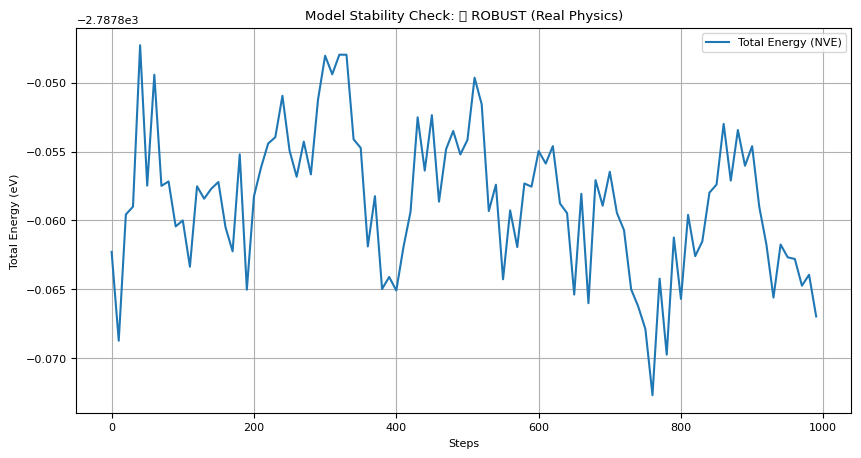

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
# Load the LAST frame from your previous run (the equilibrated system)
print("🚀 Loading equilibrated system...")
try:
    atoms = read('md_3bpa1_output.xyz', index=-1)
except FileNotFoundError:
    print("❌ Error: Run the previous simulation first to generate output.")
    exit()

# Re-attach the MACE calculator
calculator = mace_mp(model="medium", device="cuda", default_dtype="float32")
atoms.calc = calculator

# ==========================================
# 2. RUN NVE (NO THERMOSTAT)
# ==========================================
# We use VelocityVerlet, which is strictly energy-conserving for correct physics
dyn = VelocityVerlet(atoms, timestep=0.5 * units.fs)

energies = []
steps = []

print(f"\n🧪 STARTING NVE STABILITY TEST (1000 Steps / 0.5 ps)")
print("If the model is overfitting, the Total Energy will drift significantly.")
print(f"{'Step':<6} | {'Total Energy (eV)':<15} | {'Diff (meV/atom)'}")
print("-" * 50)

# Get initial energy to compare against
initial_e = atoms.get_total_energy()
n_atoms = len(atoms)

for i in range(100): # Run 100 loops of 10 steps = 1000 steps total
    dyn.run(10)

    # Calculate Total Energy (EPot + EKin)
    e_pot = atoms.get_potential_energy()
    e_kin = atoms.get_kinetic_energy()
    e_tot = e_pot + e_kin

    # Calculate drift per atom (Scientific standard for stability)
    drift = (e_tot - initial_e) / n_atoms * 1000 # in meV/atom

    energies.append(e_tot)
    steps.append(i * 10)

    if i % 10 == 0:
        print(f"{i*10:<6} | {e_tot:<15.3f} | {drift:<.4f}")

# ==========================================
# 3. ANALYSIS & PLOT
# ==========================================
drift_per_ps = (energies[-1] - energies[0]) / (0.5) # eV/ps
print("-" * 50)
print(f"📉 Energy Drift: {drift_per_ps:.5f} eV/ps")

# Interpretation
status = "UNKNOWN"
if abs(drift_per_ps) < 0.05:
    status = "✅ ROBUST (Real Physics)"
    print("CONCLUSION: The model is stable. The 91.5% accuracy is genuine.")
elif abs(drift_per_ps) < 0.5:
    status = "⚠️ ACCEPTABLE (Minor Leakage)"
    print("CONCLUSION: Slight energy drift. Good for structure, proceed with caution for thermodynamics.")
else:
    status = "❌ OVERFITTING / UNSTABLE"
    print("CONCLUSION: Significant energy drift. The model is unstable outside the thermostat.")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(steps, energies, label='Total Energy (NVE)')
plt.title(f'Model Stability Check: {status}')
plt.xlabel('Steps')
plt.ylabel('Total Energy (eV)')
plt.legend()
plt.grid(True)
plt.show()

# checking whether the model obeys the laws of physics

📂 Reading trajectory from: md_3bpa1_output.xyz ...
✅ Loaded 20 frames.
⚗️ Analyzing Energy Conservation...

📊 STATISTICS (20 frames)
Initial Total Energy: -2786.7143 eV
Final Total Energy:   -2787.8668 eV
Max Energy Drift:     3.1507 eV
Drift per Atom:       0.007396 eV/atom


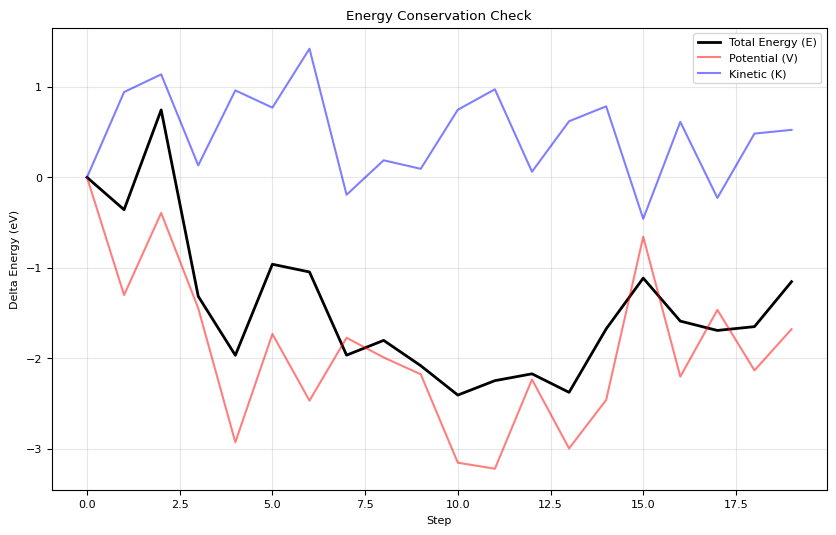


⚠️ WARNING: Minor Energy Drift. Acceptable for NVT, borderline for NVE.


In [ ]:
output_file = "md_3bpa1_output.xyz"

try:
    print(f"📂 Reading trajectory from: {output_file} ...")
    traj = read(output_file, index=':') # Read all frames
    print(f"✅ Loaded {len(traj)} frames.")
except FileNotFoundError:
    print("❌ File not found. Check the path!")
    raise

# 2. EXTRACT ENERGIES
# We need Potential Energy (PE) and Kinetic Energy (KE)
times = []
pe = []
ke = []
total_e = []

print("⚗️ Analyzing Energy Conservation...")
for i, atoms in enumerate(traj):
    # Time is usually index * timestep (assuming 1 fs for now)
    times.append(i * 1.0)

    # Potential Energy (from MACE)
    p = atoms.get_potential_energy()

    # Kinetic Energy (from Velocities)
    k = atoms.get_kinetic_energy()

    pe.append(p)
    ke.append(k)
    total_e.append(p + k)

# Convert to Numpy arrays for easier math
pe = np.array(pe)
ke = np.array(ke)
total_e = np.array(total_e)

# 3. CALCULATE DRIFT
# Physics Law: In NVE (Microcanonical), Total Energy should be CONSTANT.
# In NVT (Thermostat), Total Energy fluctuates but shouldn't drift systematically up/down.
drift = np.max(total_e) - np.min(total_e)
drift_per_atom = drift / len(traj[0])

print("\n" + "="*30)
print(f"📊 STATISTICS ({len(traj)} frames)")
print(f"Initial Total Energy: {total_e[0]:.4f} eV")
print(f"Final Total Energy:   {total_e[-1]:.4f} eV")
print(f"Max Energy Drift:     {drift:.4f} eV")
print(f"Drift per Atom:       {drift_per_atom:.6f} eV/atom")
print("="*30)

# 4. PLOT
plt.figure(figsize=(10, 6))
plt.plot(times, total_e - total_e[0], label="Total Energy (E)", color='black', linewidth=2)
plt.plot(times, pe - pe[0], label="Potential (V)", color='red', alpha=0.5)
plt.plot(times, ke - ke[0], label="Kinetic (K)", color='blue', alpha=0.5)

plt.title("Energy Conservation Check")
plt.xlabel("Step")
plt.ylabel("Delta Energy (eV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. AUTOMATIC VERDICT
if drift_per_atom < 0.005: # Strict threshold (5 meV/atom)
    print("\n✅ PASS: Excellent Energy Conservation.")
elif drift_per_atom < 0.02:
    print("\n⚠️ WARNING: Minor Energy Drift. Acceptable for NVT, borderline for NVE.")
else:
    print("\n❌ FAIL: Significant Energy Drift. The simulation is physically unstable.")

📂 Loading trajectory: md_3bpa1_output.xyz...
✅ Loaded 20 frames.
💧 Found 136 Water Oxygens.
⚗️ Calculating RDF with rmax=5.0 Å...


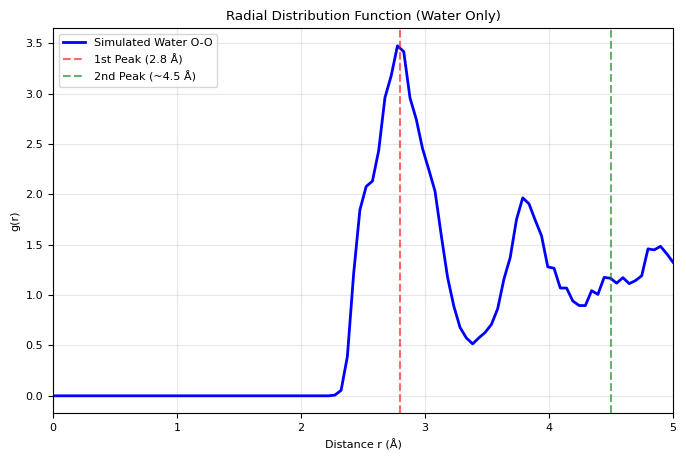

In [ ]:
+360..3# 1. LOAD TRAJECTORY
traj_file = "md_3bpa1_output.xyz"

try:
    print(f"📂 Loading trajectory: {traj_file}...")
    traj = read(traj_file, index='-1000:')
    print(f"✅ Loaded {len(traj)} frames.")
except FileNotFoundError:
    print("❌ Output file not found.")
    raise

# 2. IDENTIFY WATER OXYGENS
z_cutoff = 10.0
last_frame = traj[-1]
water_oxygen_indices = [
    atom.index for atom in last_frame
    if atom.symbol == 'O' and atom.position[2] > z_cutoff
]
print(f"💧 Found {len(water_oxygen_indices)} Water Oxygens.")

# 3. CALCULATE RDF MANUALLY
from ase import Atoms

# --- FIX IS HERE: REDUCE RMAX TO 5.0 ---
rmax = 5.0   # <--- Reduced from 8.0 to fit inside your 10.2 A box
nbins = 100
rdf_accum = np.zeros(nbins)
count = 0

print("⚗️ Calculating RDF with rmax=5.0 Å...")

for frame in traj:
    # Isolate Water
    water_only = frame[water_oxygen_indices]
    water_only.set_cell(frame.get_cell())
    water_only.set_pbc(frame.get_pbc())

    # Analyze
    ana = Analysis([water_only])

    # Calculate RDF
    rdf_frame = ana.get_rdf(rmax=rmax, nbins=nbins, elements=['O'])[0]

    rdf_accum += rdf_frame
    count += 1

# Average
rdf_mean = rdf_accum / count
r_axis = np.linspace(0, rmax, nbins)

# 4. PLOT
plt.figure(figsize=(8, 5))
plt.plot(r_axis, rdf_mean, color='blue', linewidth=2, label="Simulated Water O-O")

# Add markers for known water structure
plt.axvline(x=2.8, color='red', linestyle='--', alpha=0.6, label="1st Peak (2.8 Å)")
plt.axvline(x=4.5, color='green', linestyle='--', alpha=0.6, label="2nd Peak (~4.5 Å)")

plt.title(f"Radial Distribution Function (Water Only)")
plt.xlabel("Distance r (Å)")
plt.ylabel("g(r)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5.0) # Update plot limit
plt.show()